# Day01 라이브2 실습 참고 자료

## NumPy

### page 7 : 파이썬의 리스트와 NumPy의 배열 비교

#### 파이썬의 리스트

In [1]:
# Python`s list
prices = [1000, 4000, 2500, 3300]
print("prices * 2 : ", prices * 2)

incre = [500, 300, 150, 400]
print("prices + incre : ", prices + incre)

# 리스트의 결합이 아닌 각 인덱스별 합 구하기
# 1. 가장 직관적인 방법
plus = []
for i in range(len(prices)):
    plus.append(prices[i] + incre[i])

print("plus : ", plus)

# 2. zip과 리스트 컴프리헨션 사용 방법
# zip(prices, incre)는 두 리스트의 같은 위치에 있는 값을 하나의 쌍으로 묶습니다.
print("list(zip(prices, incre)) : ", list(zip(prices, incre)))

result = []
# for price, increase in zip(prices, incre):
#     result.append(price + increase)

result = [price + increase for price, increase in zip(prices, incre)]

print("result : ", result)

prices * 2 :  [1000, 4000, 2500, 3300, 1000, 4000, 2500, 3300]
prices + incre :  [1000, 4000, 2500, 3300, 500, 300, 150, 400]
plus :  [1500, 4300, 2650, 3700]
list(zip(prices, incre)) :  [(1000, 500), (4000, 300), (2500, 150), (3300, 400)]
result :  [1500, 4300, 2650, 3700]


#### NumPy의 ndarray

In [2]:
import numpy as np

prices_array = np.array(prices)
incre_array = np.array(incre)
print(type(prices_array))

result = prices_array + incre_array
# result = np.array(prices) + np.array(incre)

print("ndarray result: ", result)

<class 'numpy.ndarray'>
ndarray result:  [1500 4300 2650 3700]


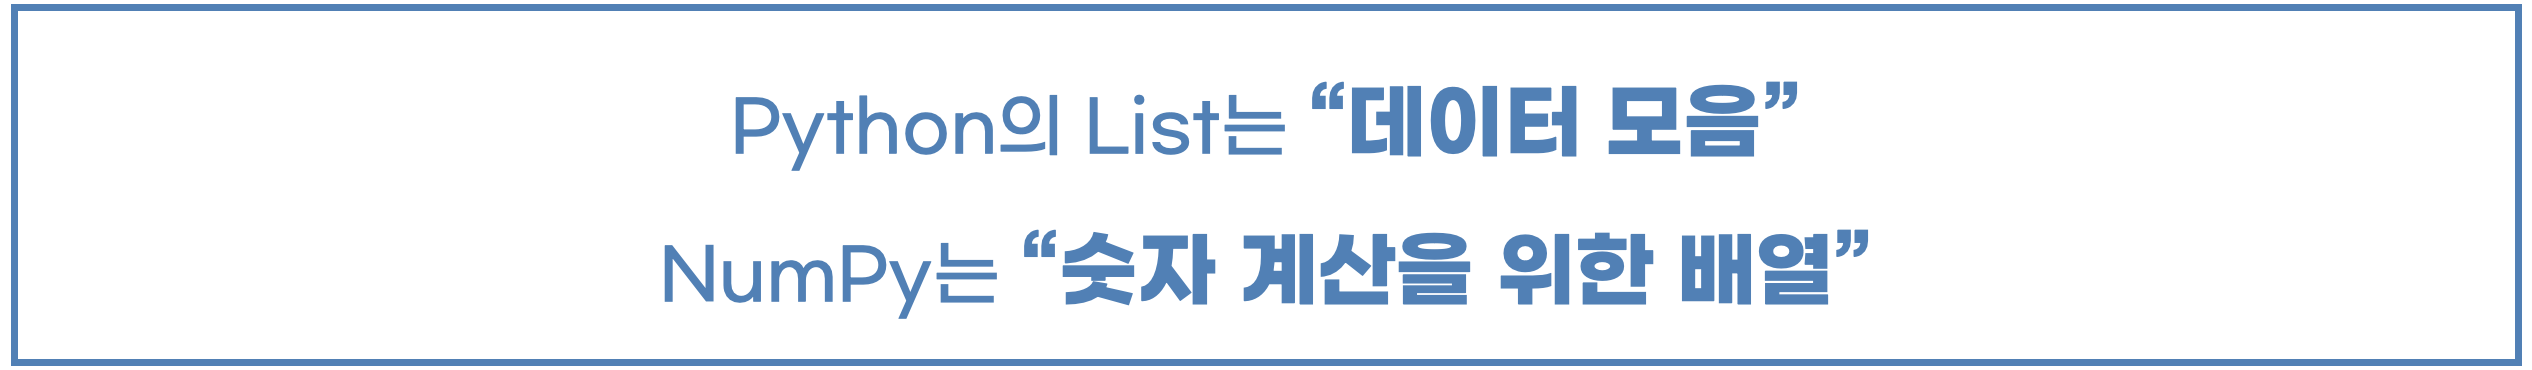

In [3]:
# 참고만
scalar_str = "abcd"
str_arr = np.array(scalar_str)
# print(str_arr[0])  # error
print(str_arr.ndim)  # 0차원 배열, 즉 Scalar Array (0차원 배열)은 인덱싱 불가
print(str_arr.shape)

# 해결
str_arr = np.array(list(scalar_str))
print(str_arr[0])

0
()
a


### page 9: 같은 자료형의 데이터를 연속된 메모리 공간에 저장

In [4]:
# 다른 데이터 타입의 자료형을 갖는 list를 ndarray로 변경하는 에러?
plist = [1, 2, "a", "asd", True]
print("Python List: ", plist)
ndarray = np.array(plist)
print("ndarray", ndarray)
print("ndarray type: ", ndarray.dtype)  # <U21 --> NumPy는 이 배열을 문자열 배열이라고 판단
# <  : little endian
# U  : Unicode 문자열
# 21 : 최대 21개의 Unicode 문자 저장

# dtype 추론: np.array(...)의 모든 데이터를 검사 후 모든 원소를 저장할 수 있는 하나의 dtype을 찾음
plist2 = [1, 2, 3.5]
ndarray2 = np.array(plist2)
print("ndarray type: ", ndarray2.dtype)  # float64
print("ndarray2: ", ndarray2)

# 에러가 발생하는 경우: 사용자가 dtype을 강제로 지정하면 에러가 발생
plist = [1, False, 2, "python", True] # False는 에러 발생 X >> 자동 형변환
# ndarray = np.array(plist, dtype=int)

Python List:  [1, 2, 'a', 'asd', True]
ndarray ['1' '2' 'a' 'asd' 'True']
ndarray type:  <U21
ndarray type:  float64
ndarray2:  [1.  2.  3.5]


### page 10: 연산 속도 비교

In [5]:
import time

# 1. Python 리스트 연산 시간 측정
start_time = time.perf_counter() # 현재 날짜나 시각을 의미하는것이 아닌 운영체제가 정한 임의의 기준점부터 흐른 시간을 초 단위로 나타낸 값
list_sum = sum(range(1_000_000))
print(f"Python List 소요 시간 : {time.perf_counter() - start_time:.5f}초")

Python List 소요 시간 : 0.01101초


In [6]:
# 2. Numpy 배열 연산 시간 측정
arr = np.arange(1_000_000)
start_time = time.perf_counter()
arr_sum = arr.sum()
print(f"Numpy Array 소요 시간 : {time.perf_counter() - start_time:.5f}초")

print(arr_sum, list_sum)

Numpy Array 소요 시간 : 0.00022초
499999500000 499999500000


### AI에서의 NumPy

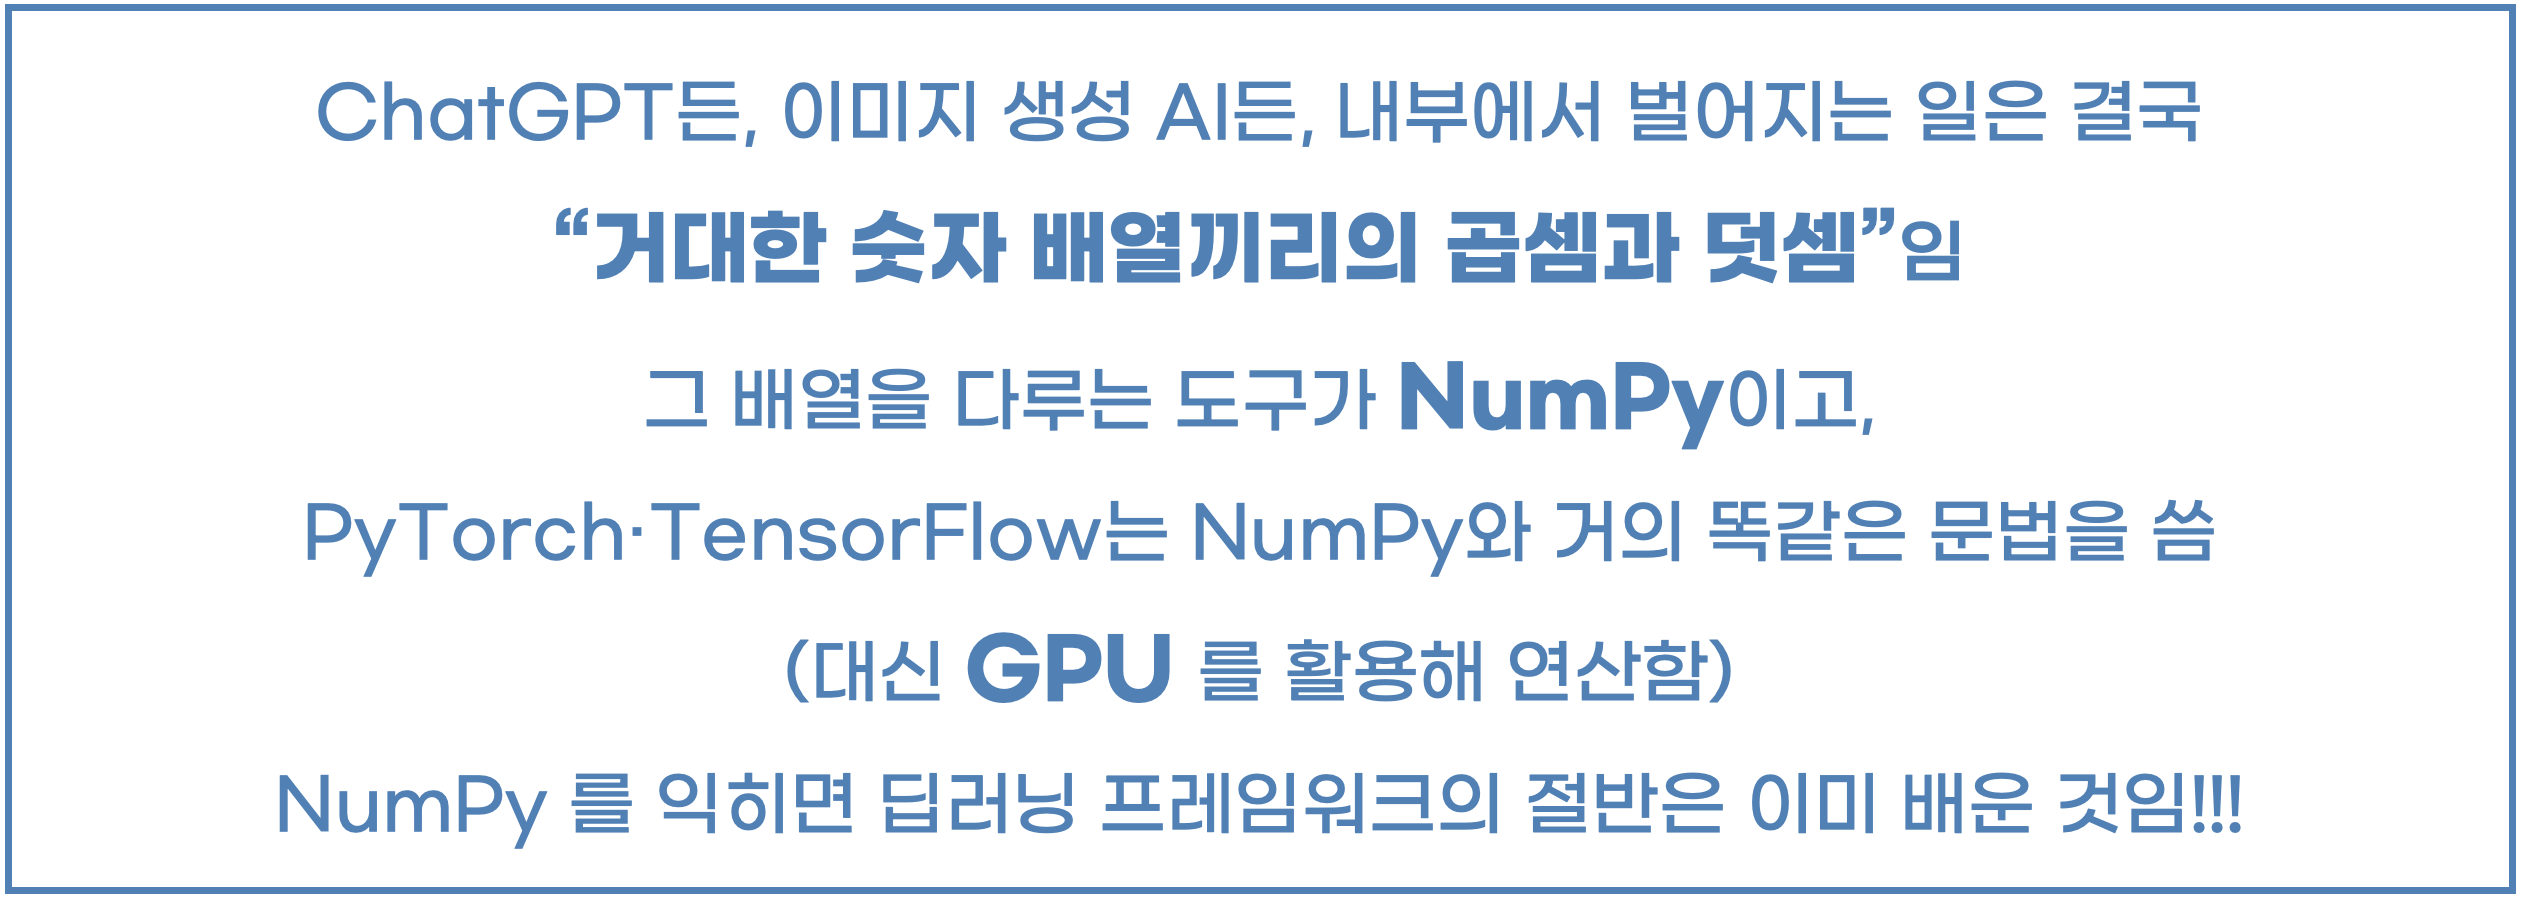

### page 11: NumPy 배열 만들기

 - 차원 (Dimension)과 축 (Axis)
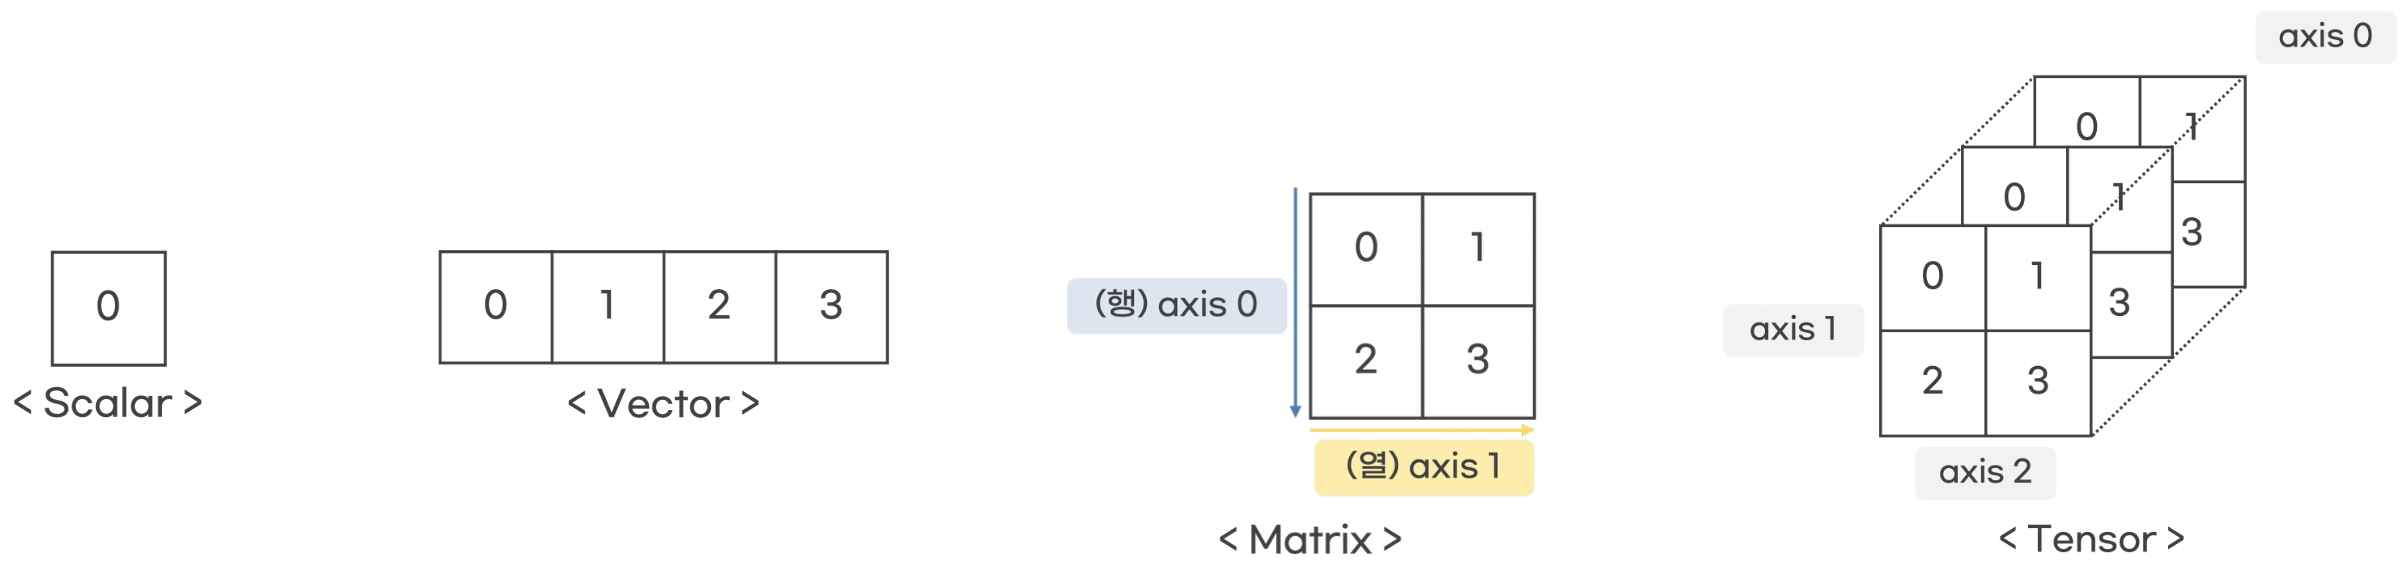

In [7]:
# NumPy 배열 생성
list = [10, 20, 30, 40]
print(type(list))
print("Python List: ", list)

ndarray = np.array(list)
print(type(ndarray))
print("NumPy ndarray (Vector): ", ndarray)
print("ndarray 차원: ", ndarray.ndim)
print("각 차원의 크기: ", ndarray.shape)

print("--" * 20)

list = [[1, 2], [3, 4], [5, 6]]
ndarray = np.array(list)
print("NumPy ndarray (Matrix): \n", ndarray)
print("ndarray 차원: ", ndarray.ndim)
print("각 차원의 크기: ", ndarray.shape)

print("--" * 20)

list = [
    [[1, 2, 3], [4, 5, 6], [7, 8, 9], [1, 2, 3]],
    [[10, 20, 30], [40, 50, 60], [70, 80, 90], [10, 20, 30]]
]
ndarray = np.array(list)
print("NumPy ndarray (Tensor): \n", ndarray)
print("ndarray 차원: ", ndarray.ndim)
print("각 차원의 크기: ", ndarray.shape)

<class 'list'>
Python List:  [10, 20, 30, 40]
<class 'numpy.ndarray'>
NumPy ndarray (Vector):  [10 20 30 40]
ndarray 차원:  1
각 차원의 크기:  (4,)
----------------------------------------
NumPy ndarray (Matrix): 
 [[1 2]
 [3 4]
 [5 6]]
ndarray 차원:  2
각 차원의 크기:  (3, 2)
----------------------------------------
NumPy ndarray (Tensor): 
 [[[ 1  2  3]
  [ 4  5  6]
  [ 7  8  9]
  [ 1  2  3]]

 [[10 20 30]
  [40 50 60]
  [70 80 90]
  [10 20 30]]]
ndarray 차원:  3
각 차원의 크기:  (2, 4, 3)


### page 13: 전치행렬
 - 전치 (행과 열 교환) 행렬로 변경: array.T == array.transpose()


In [8]:
array = np.arange(6).reshape(2, 3)
print(array)
print(array.shape)
array_t = array.T
print(array_t)
print(array_t.shape)

[[0 1 2]
 [3 4 5]]
(2, 3)
[[0 3]
 [1 4]
 [2 5]]
(3, 2)


### page 15: 집계함수

In [9]:
list = [8000, 4500, 15000, 25000, 6000]
arr = np.array([8000, 4500, 15000, 25000, 6000])
print(arr.sum())
print(np.sum(list))
print(arr.mean())
print(np.mean(list))
print(arr.max())
print(arr.min())
print(arr.std())

58500
58500
11700.0
11700.0
25000
4500
7560.42326857432


### page 16: 브로드캐스팅 (Broadcasting)
 - 브로드 캐스팅 (Broadcasting): 형태가 다른 배열을 연산할 수 있도록 배열의 형태를 동적으로 변환
 - 작은 배열이 큰 배열의 형태에 맞게 복제되어 연산 됨
 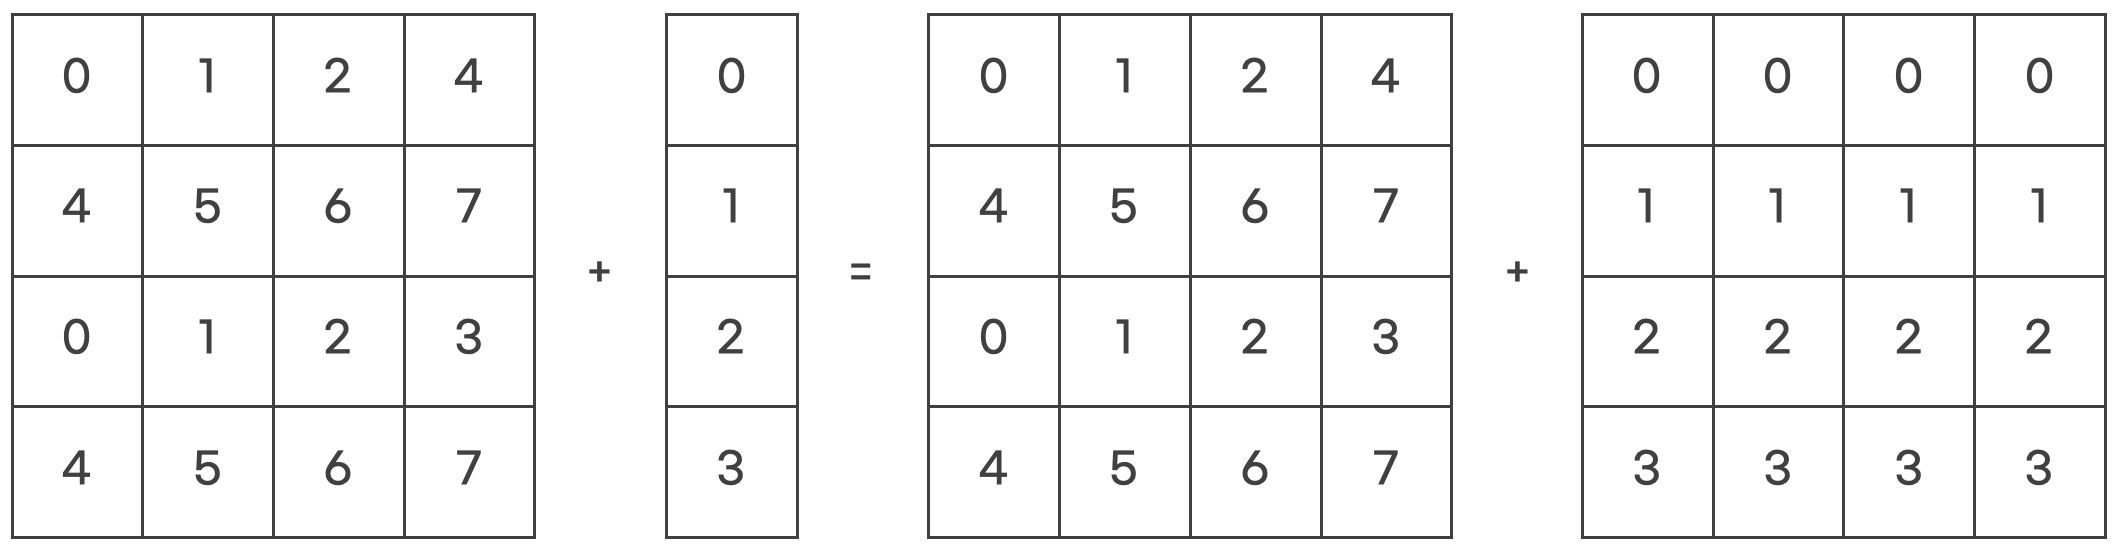

In [10]:
array1 = np.arange(1, 5).reshape(2, 2)
print(array1)
array2 = np.arange(1, 3)
print(array2)
array3 = array1 + array2
print(array3)

[[1 2]
 [3 4]]
[1 2]
[[2 4]
 [4 6]]


In [11]:
array1 = np.arange(1, 7).reshape(3, 2)
print(array1)
print(array1.shape)
array2 = np.arange(1, 4)
print("newaxis 이전: ", array2)
array2 = array2[:, np.newaxis]
print(array2)
print(array2.shape)
print("--" * 20)
array3 = array1 + array2
print(array3)

[[1 2]
 [3 4]
 [5 6]]
(3, 2)
newaxis 이전:  [1 2 3]
[[1]
 [2]
 [3]]
(3, 1)
----------------------------------------
[[2 3]
 [5 6]
 [8 9]]


In [12]:
array1 = np.arange(1, 7).reshape(3, 2)
print(array1)
print(array1.shape)
array2 = np.arange(1, 4).reshape(3, 1)
print(array2)
print(array2.shape)
print("--" * 20)
array3 = array1 + array2
print(array3)

[[1 2]
 [3 4]
 [5 6]]
(3, 2)
[[1]
 [2]
 [3]]
(3, 1)
----------------------------------------
[[2 3]
 [5 6]
 [8 9]]


In [13]:
단가 = np.array([4000, 5000, 6000])
수량 = np.array([[1, 2], [3, 1], [5, 2]])
print(단가.shape)
print(수량.shape)

결과 = 단가[:, np.newaxis] * 수량
print(결과)

결과 = 단가.reshape(3, 1) * 수량
print(결과)

(3,)
(3, 2)
[[ 4000  8000]
 [15000  5000]
 [30000 12000]]
[[ 4000  8000]
 [15000  5000]
 [30000 12000]]


## Pandas

### 왜!!! Pandas ?
 - NumPy로 처리할때의 문제점
    * 여러 타입이 섞여 있을 경우 전부 문자열로 됨 ::> 나이의 평균 구하기 힘듬
    * 열 이름이 없음 ::> 요금을 알아 보려면 data[:, 4] ::> 4번째 인덱스가 요금을 나타내는지 매번 확인 필요
    * 결측치를 처리할 방법이 없음 ::> 나이가 비어 있는 데이터의 경우 어떻게 표현?
  

In [14]:
# data = np.array([[0, 3, "male", 22.0, 7.2500, "S"],
#                  [1, 1, "female", 38.0, 71.2833, "C"]])
data = np.genfromtxt("titanic.csv", delimiter=",",
                     usecols=(0, 1, 2, 3, 6, 7),  skip_header=1, dtype=str)

print(data.dtype)   # <U8 : 전부 문자열로 변경
print(data[:, 3])   # ['7.25' '71.2833'] : 나이도 문자열 !!!
# data[:, 3].mean()   # 문자열은 평균을 못 냄 ::> Error !!!

<U8
['22.0' '38.0' '26.0' '35.0' '35.0' '' '54.0' '2.0' '27.0' '14.0' '4.0'
 '58.0' '20.0' '39.0' '14.0' '55.0' '2.0' '' '31.0' '' '35.0' '34.0'
 '15.0' '28.0' '8.0' '38.0' '' '19.0' '' '' '40.0' '' '' '66.0' '28.0'
 '42.0' '' '21.0' '18.0' '14.0' '40.0' '27.0' '' '3.0' '19.0' '' '' '' ''
 '18.0' '7.0' '21.0' '49.0' '29.0' '65.0' '' '21.0' '28.5' '5.0' '11.0'
 '22.0' '38.0' '45.0' '4.0' '' '' '29.0' '19.0' '17.0' '26.0' '32.0'
 '16.0' '21.0' '26.0' '32.0' '25.0' '' '' '0.83' '30.0' '22.0' '29.0' ''
 '28.0' '17.0' '33.0' '16.0' '' '23.0' '24.0' '29.0' '20.0' '46.0' '26.0'
 '59.0' '' '71.0' '23.0' '34.0' '34.0' '28.0' '' '21.0' '33.0' '37.0'
 '28.0' '21.0' '' '38.0' '' '47.0' '14.5' '22.0' '20.0' '17.0' '21.0'
 '70.5' '29.0' '24.0' '2.0' '21.0' '' '32.5' '32.5' '54.0' '12.0' ''
 '24.0' '' '45.0' '33.0' '20.0' '47.0' '29.0' '25.0' '23.0' '19.0' '37.0'
 '16.0' '24.0' '' '22.0' '24.0' '19.0' '18.0' '19.0' '27.0' '9.0' '36.5'
 '42.0' '51.0' '22.0' '55.5' '40.5' '' '51.0' '16.0' '30.0' '' '' 

 - Pandas 맛보기

In [15]:
import pandas as pd

df = pd.read_csv("titanic.csv") # csv파일을 한줄로 로딩
print("나이 평균: ", df["age"].mean())         # 나이 평균: 29.699... ::> 결측치는 알아서 제외
print("최고 요금: ", df["fare"].max())         # 최고 요금: 512.3292
print("여성의 생존률: ", df[df["sex"] == "female"]["survived"].mean()) # 0.742...

# 아래의 한 줄로 "여성 생존률: 74.2%, 남성 생존률: 18.9%"를 알 수 있음
print("성별 생존률\n", df.groupby("sex")["survived"].mean())
# sex
# female    0.742038
# male      0.188908
# Name: survived, dtype: float64

print(df.index)
print(df.columns)
print(type(df["age"])) # <class 'pandas.Series'>
print(type(df["age"].values)) # <class 'numpy.ndarray'>

나이 평균:  29.69911764705882
최고 요금:  512.3292
여성의 생존률:  0.7420382165605095
성별 생존률
 sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
RangeIndex(start=0, stop=891, step=1)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
<class 'pandas.Series'>
<class 'numpy.ndarray'>


### NumPy vs Pandas

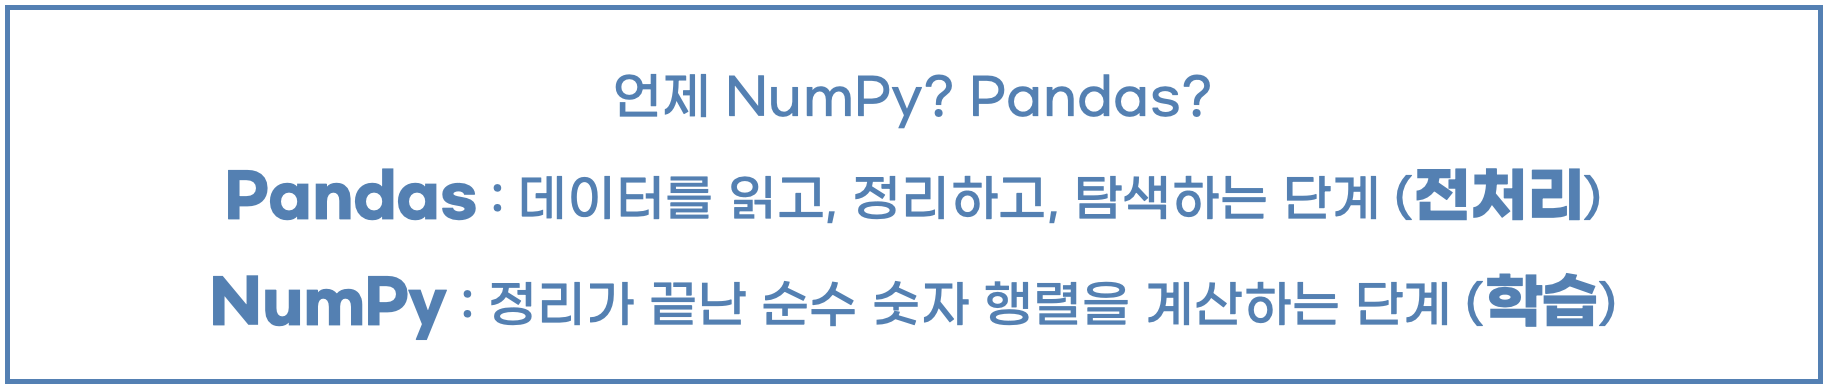


### Pandas
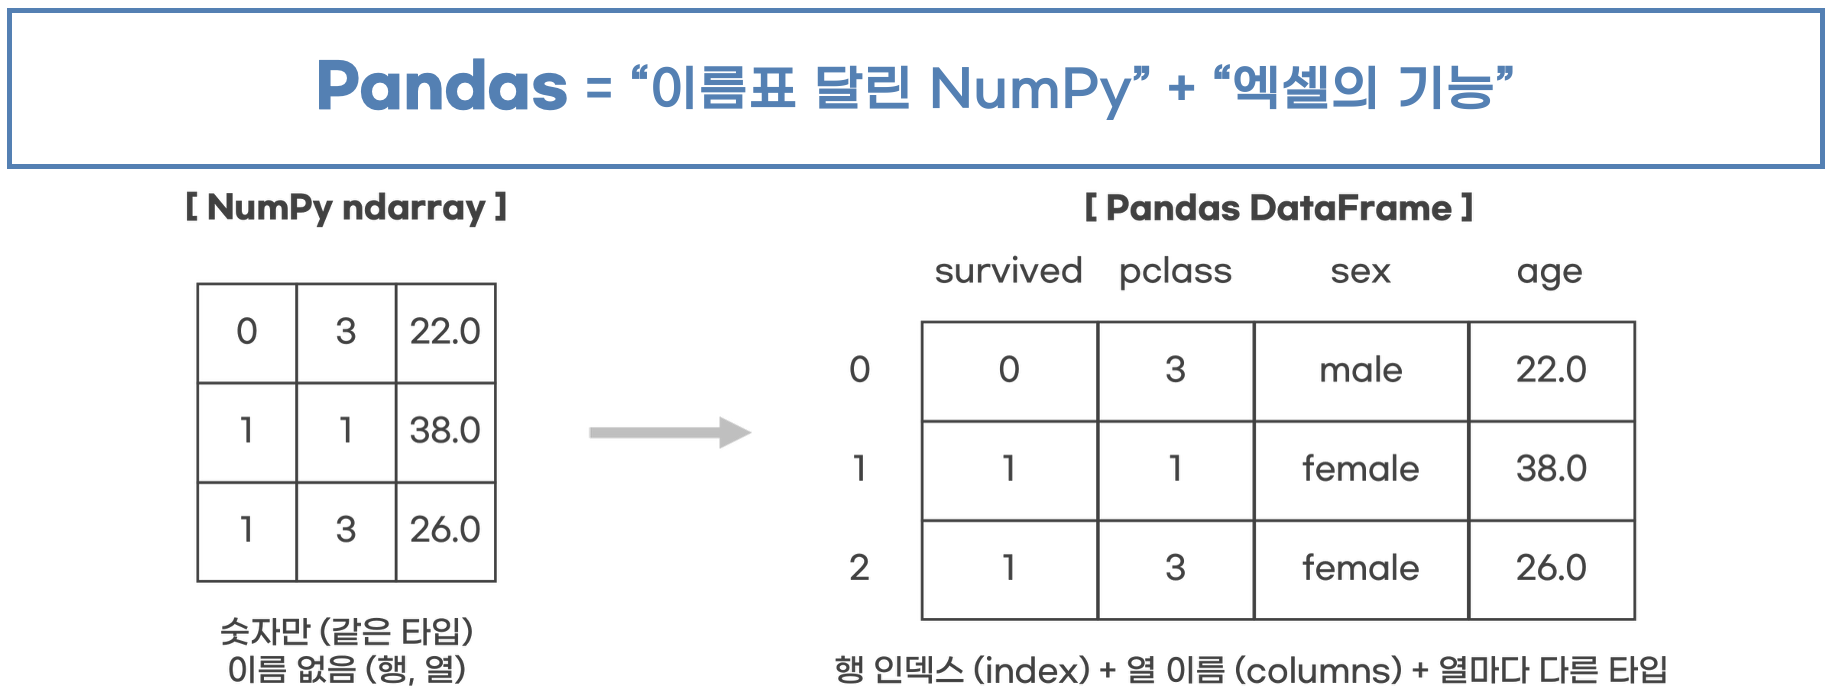

### page 22: Series & DataFrame

 - 기본 데이터 구조로 1차원 배열 형태인 시리즈 (Series)와 2차원 배열 형태인 데이터프레임 (DataFrame)이 있음
 
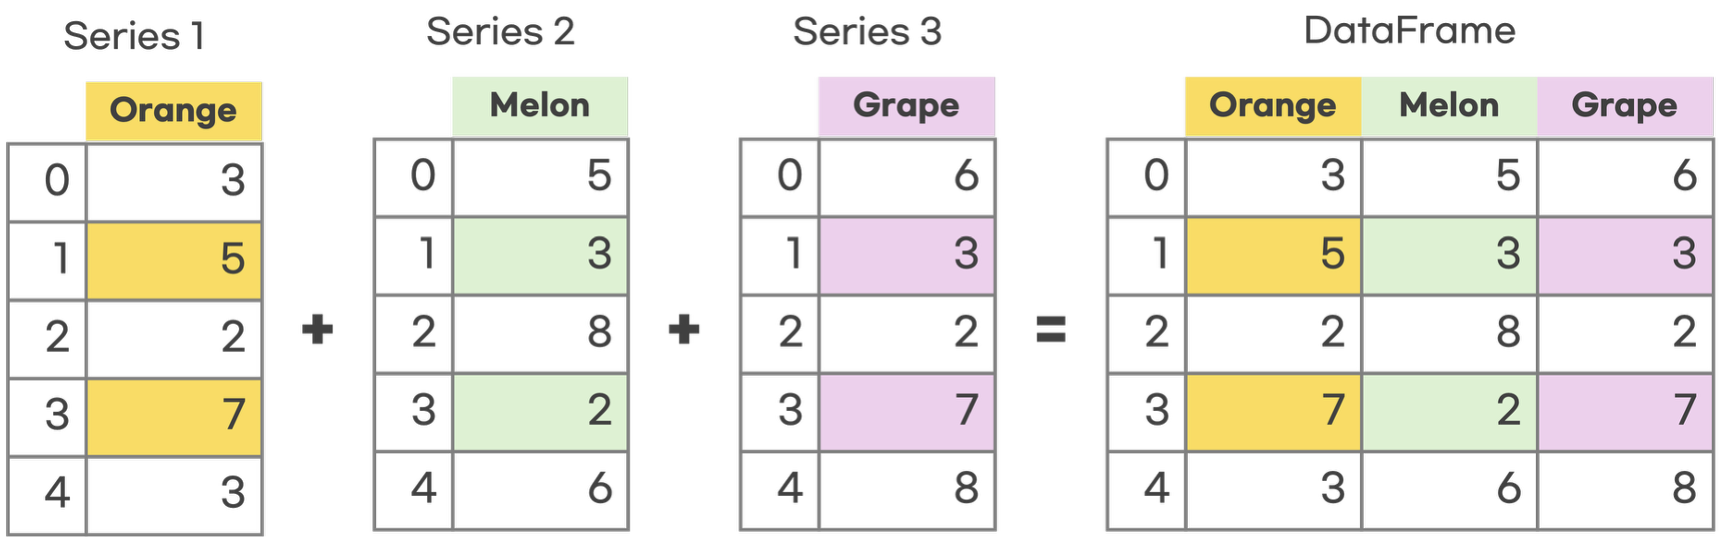

### page 23: DataFrame 구조
 - 딕셔너리로 DataFrame 생성

In [16]:
df_dic = pd.DataFrame({
    '메뉴': ['아메리카노', '카페라떼'],
    '단가': [4000, 5000]
})

# display(df)                     # 표 형태로 출력
print(df_dic)
print(df_dic.index)                 # RangeIndex(start=0, stop=2, step=1)
print(df_dic.columns)               # Index(['메뉴 ', '단가 '], dtype='str')
print("--" * 20)
print(type(df_dic['단가']))          # <class 'pandas.Series'>
print(df_dic['단가'])
print("--" * 20)
print(type(df_dic['단가'].values))   # <class 'numpy.ndarray'>
print(df_dic['단가'].values)

      메뉴    단가
0  아메리카노  4000
1   카페라떼  5000
RangeIndex(start=0, stop=2, step=1)
Index(['메뉴', '단가'], dtype='str')
----------------------------------------
<class 'pandas.Series'>
0    4000
1    5000
Name: 단가, dtype: int64
----------------------------------------
<class 'numpy.ndarray'>
[4000 5000]


### page 34: **loc** 이름표 (Label) vs **iloc** 순서 (위치, integer postion)

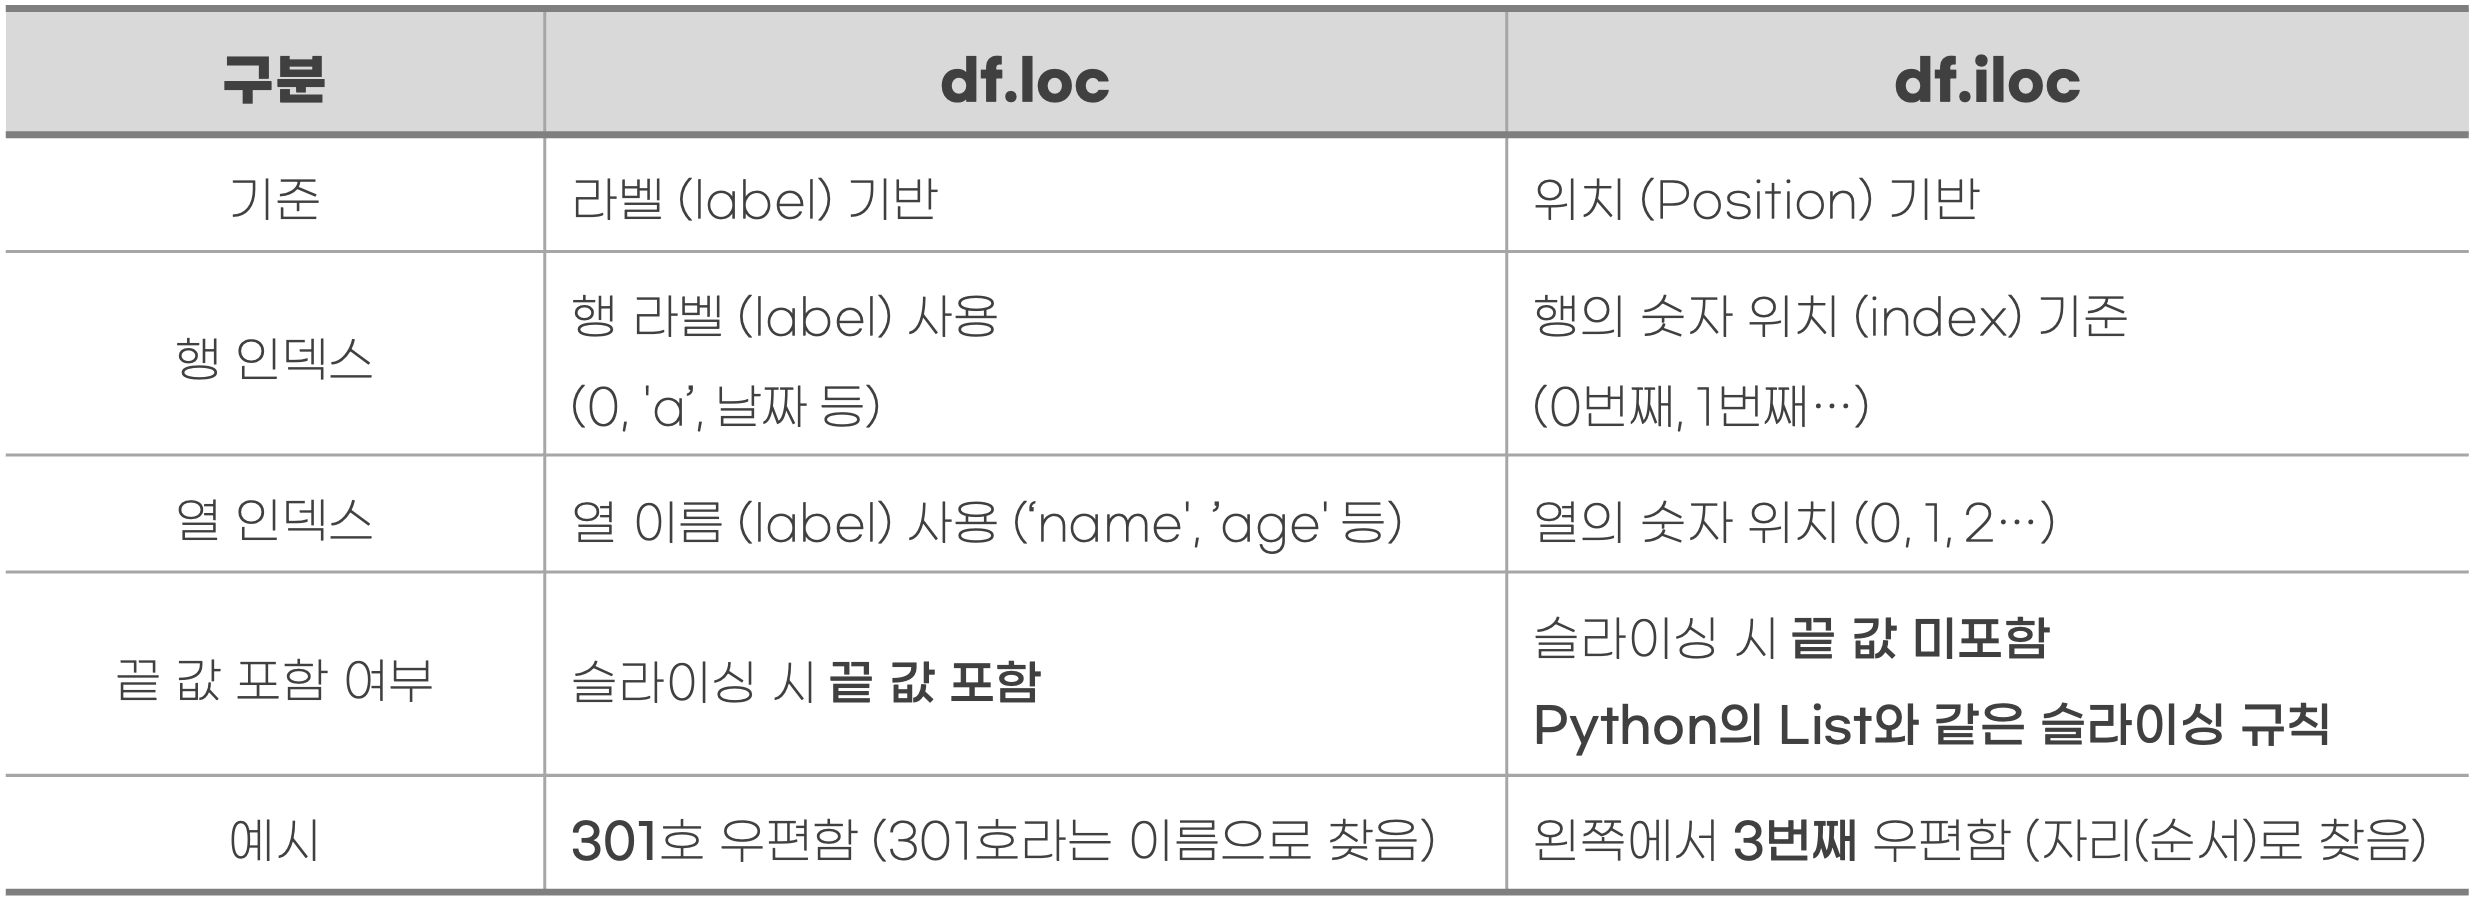

In [17]:
# 행 이름표 (index): a, b, c, d, e, f, g
# 열 이름표 (column): 이름, 나이, 직업, 급여
data = {
    '이름': ['김현철', '이영희', '박민수', '최지영', '정수빈', '김태희', '나성빈'],
    '나이': [25, 28, 22, 30, 34, 40, 31],
    '직업': ['학생', '회사원', '학생', '회사원', '프리랜서', '회사원', '프리랜서'],
    '급여': [0, 3000, 0, 3500, 4500, 8000, 4200]
}

df = pd.DataFrame(data, index=['a', 'b', 'c', 'd', 'e', 'f', 'g'])
print(df)

    이름  나이    직업    급여
a  김현철  25    학생     0
b  이영희  28   회사원  3000
c  박민수  22    학생     0
d  최지영  30   회사원  3500
e  정수빈  34  프리랜서  4500
f  김태희  40   회사원  8000
g  나성빈  31  프리랜서  4200


 - loc[행 이름, 열 이름] vs iloc[행 위치, 열 위치]

In [18]:
# loc (이름표로 꺼내기)
display(df.loc['a'])                # 이름표가 'a'인 행
display(df.loc['a', '직업'])         # '학생'
display(df.loc['c', '이름'])         # '박민수'
display(df.loc[:, '직업'])           # 직업 열 전체
display(df.loc['a':'c'])            # a, b, c 행 ::> c도 포함!
display(df.loc[['a', 'd']])         # a행과 d행만
display(df.loc['a', ['이름','직업']]) # a행의 이름, 직업만

print('--' * 20)

#iloc (자리 번호로 꺼내기)
display(df.iloc[0])          # 0번째 행 전체 → 김철수 행
display(df.iloc[0, 2])       # 0번째 행, 2번째 열 → '학생'
display(df.iloc[2, 0])       # 2번째 행, 0번째 열 → '박민수'
display(df.iloc[:, 2])       # 모든 행, 1번째 열 → 국어 열 전체
display(df.iloc[0:2])        # 0,1번째 행 (2번은 제외!)
display(df.iloc[[0, 3]])     # 0번째와 3번째 행만 골라서
display(df.iloc[-1])         # 맨 마지막 행 (파이썬 리스트와 동일)

이름    김현철
나이     25
직업     학생
급여      0
Name: a, dtype: object

'학생'

'박민수'

a      학생
b     회사원
c      학생
d     회사원
e    프리랜서
f     회사원
g    프리랜서
Name: 직업, dtype: str

,이름,나이,직업,급여
a,김현철,25,학생,0
b,이영희,28,회사원,3000
c,박민수,22,학생,0


...

'박민수'

a      학생
b     회사원
c      학생
d     회사원
e    프리랜서
f     회사원
g    프리랜서
Name: 직업, dtype: str

,이름,나이,직업,급여
a,김현철,25,학생,0
b,이영희,28,회사원,3000


,이름,나이,직업,급여
a,김현철,25,학생,0
d,최지영,30,회사원,3500


이름     나성빈
나이      31
직업    프리랜서
급여    4200
Name: g, dtype: object

 - 조건으로 고르는건 loc[조건, 열 이름]만 가능

In [19]:
display(df.loc[df['급여'] >= 4000])                             # 급여가 4000 이상인 행
display(df.loc[df['급여'] >= 4000, '이름'])                      # 그 사람의 이름만
display(df.loc[(df['급여'] >= 4000) & (df['이름'] == '김태희')])   # 이름이 '김태희'만

,이름,나이,직업,급여
e,정수빈,34,프리랜서,4500
f,김태희,40,회사원,8000
g,나성빈,31,프리랜서,4200


e    정수빈
f    김태희
g    나성빈
Name: 이름, dtype: str

,이름,나이,직업,급여
f,김태희,40,회사원,8000


### page 35: groupby() 집계함수

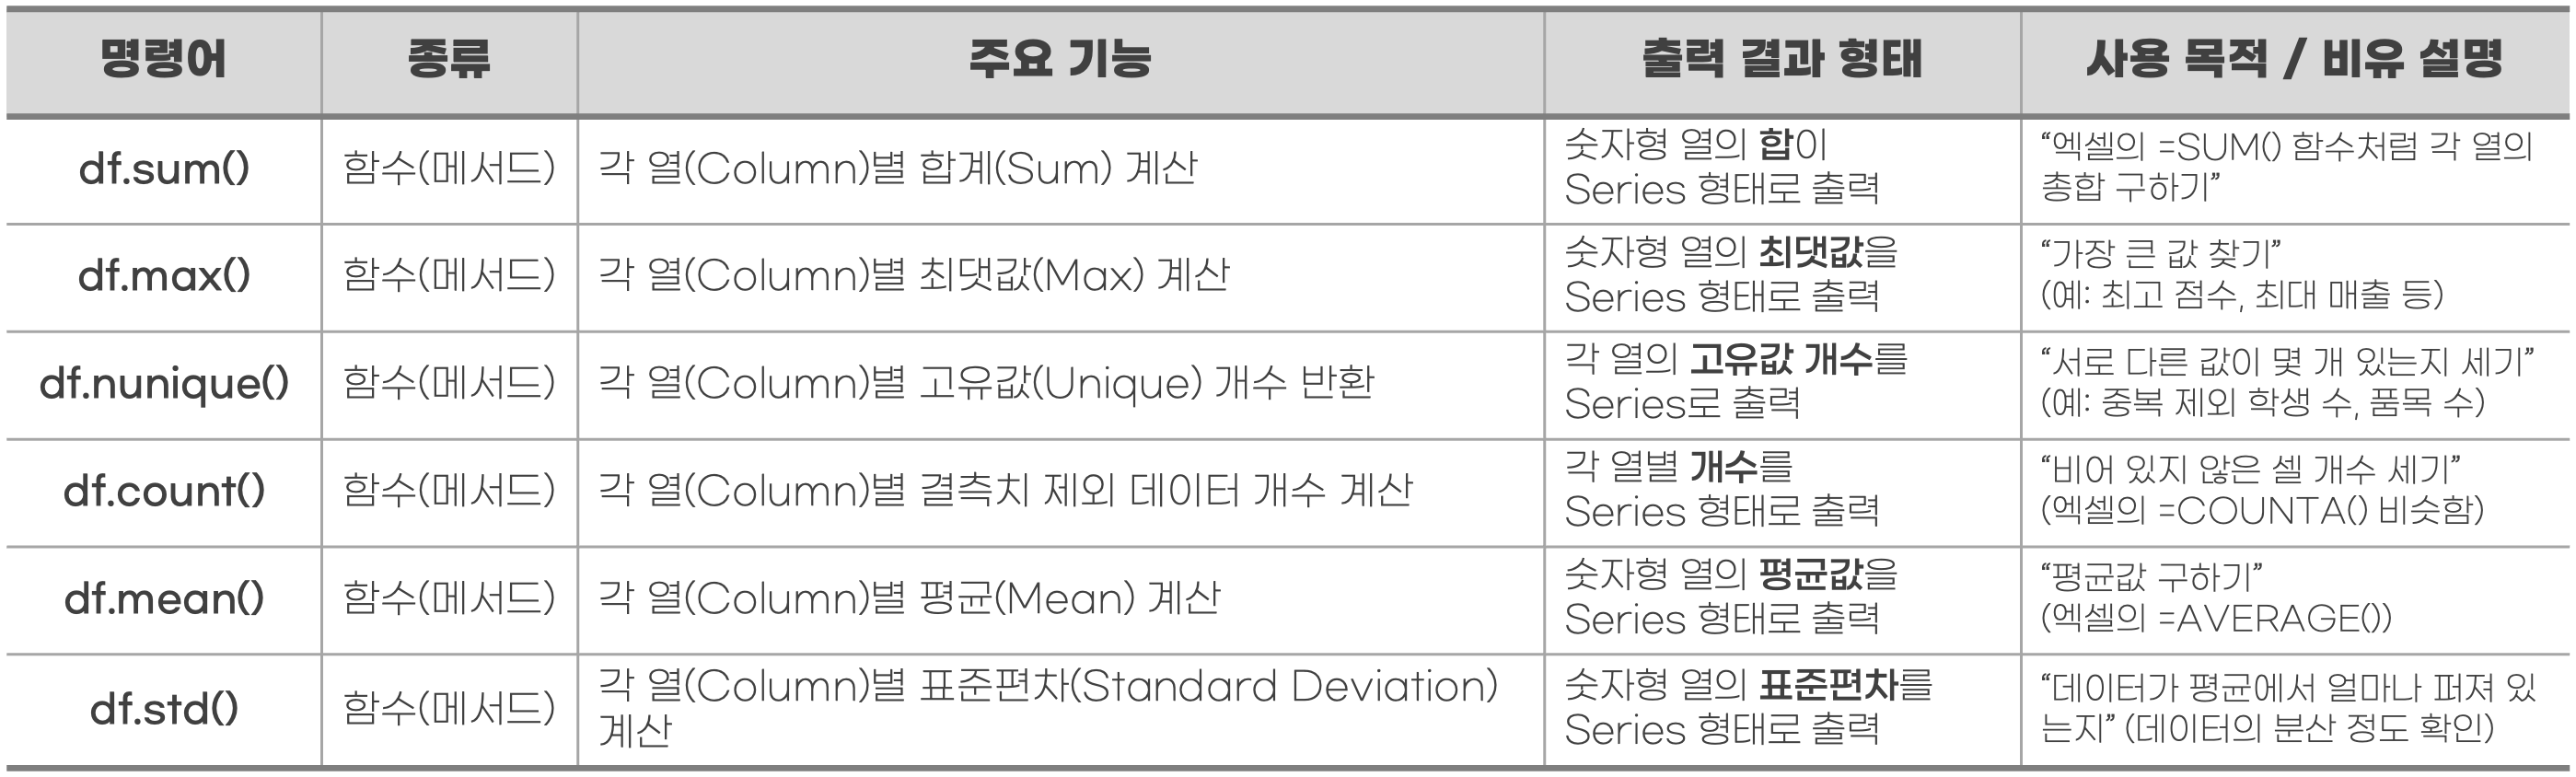

In [20]:
# 자주 쓰는 집계 함수
# 직업별 급여의
print(df.groupby('직업')['급여'].sum())     # 합계
print(df.groupby('직업')['급여'].max())     # 최댓값
print(df.groupby('직업')['급여'].min())     # 최솟값
print(df.groupby('직업')['급여'].median())  # 중앙값
print(df.groupby('직업')['급여'].std())     # 표준편차
print(df.groupby('직업')['급여'].count())   # 개수 (결측치 제외)
print(df.groupby('직업').size())     # 그룹별 행 수 (결측 포함)

직업
프리랜서     8700
학생          0
회사원     14500
Name: 급여, dtype: int64
직업
프리랜서    4500
학생         0
회사원     8000
Name: 급여, dtype: int64
직업
프리랜서    4200
학생         0
회사원     3000
Name: 급여, dtype: int64
직업
프리랜서    4350.0
학생         0.0
회사원     3500.0
Name: 급여, dtype: float64
직업
프리랜서     212.132034
학생         0.000000
회사원     2753.785274
Name: 급여, dtype: float64
직업
프리랜서    2
학생      2
회사원     3
Name: 급여, dtype: int64
직업
프리랜서    2
학생      2
회사원     3
dtype: int64


 - 컬럼마다 다른 집계 함수를 적용하고 결과의 열 이름을 직접 지정
    - agg(결과열이름=('컬럼명', '집계함수명'))

In [ ]:
df.groupby('직업').agg(
    인원수=('이름', 'count'),
    평균나이=('나이', 'mean'),
    평균급여=('급여', 'mean'),
    최고급여=('급여', 'max')
).reset_index()

,직업,인원수,평균나이,평균급여,최고급여
0,프리랜서,2,32.500000,4350.000000,4500
1,학생,2,23.500000,0.000000,0
2,회사원,3,32.666667,4833.333333,8000


 - pivot_table 사용 전
 

In [22]:
# 기존 df에 연령대 추가
df['연령대'] = (df['나이'] // 10 * 10).astype(str) + '대'
display(df)

# 행 라벨이 2단으로 쌓여있는 형태
display(df.groupby(['직업', '연령대'])['급여'].mean())

# unstack()을 이용하여 2차원 표 형태로 변경
df.groupby(['직업', '연령대'])['급여'].mean().unstack()

,이름,나이,직업,급여,연령대
a,김현철,25,학생,0,20대
b,이영희,28,회사원,3000,20대
c,박민수,22,학생,0,20대
d,최지영,30,회사원,3500,30대
e,정수빈,34,프리랜서,4500,30대
f,김태희,40,회사원,8000,40대
g,나성빈,31,프리랜서,4200,30대


직업    연령대
프리랜서  30대    4350.0
학생    20대       0.0
회사원   20대    3000.0
      30대    3500.0
      40대    8000.0
Name: 급여, dtype: float64

연령대,20대,30대,40대
직업,,,
프리랜서,NaN,4350.0,NaN
학생,0.0,NaN,NaN
회사원,3000.0,3500.0,8000.0


 - pivot_table 사용

In [23]:
# 직업, 연령대별 급여의 평균
df.pivot_table(index='직업', columns='연령대', values='급여', aggfunc='mean')

# 여러 계산을 동시에
df.pivot_table(index='직업', values='급여', aggfunc=['mean', 'max', 'min', 'count'])

,mean,max,min,count
,급여,급여,급여,급여
직업,,,,
프리랜서,4350.000000,4500,4200,2
학생,0.000000,0,0,2
회사원,4833.333333,8000,3000,3
